In [16]:
%run "/home/nichettg/Linux Programmi/Codici/moduli.py"

In [17]:
def nome (stringa):
    stringa_nuova = stringa.replace('./Data/tors_','').replace('.csv','').replace('h','H')
    return stringa_nuova

# 1. Raccolta Dati

In [18]:
input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir('./Data'))]
dati= {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    dati[nome(input_file)] = {
        "tempo": letti["Tempo"],
        "forzante": letti["Forzante"],
        "pendolo" : letti["Pendolo"],
        "ampiezza" : letti["Ampiezza"],
        "fase" : letti["Fase"],
    }

In [19]:
gf.display_dizionario(dati)

# 2. Analisi

## 2.1 Confronto Frequenze

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


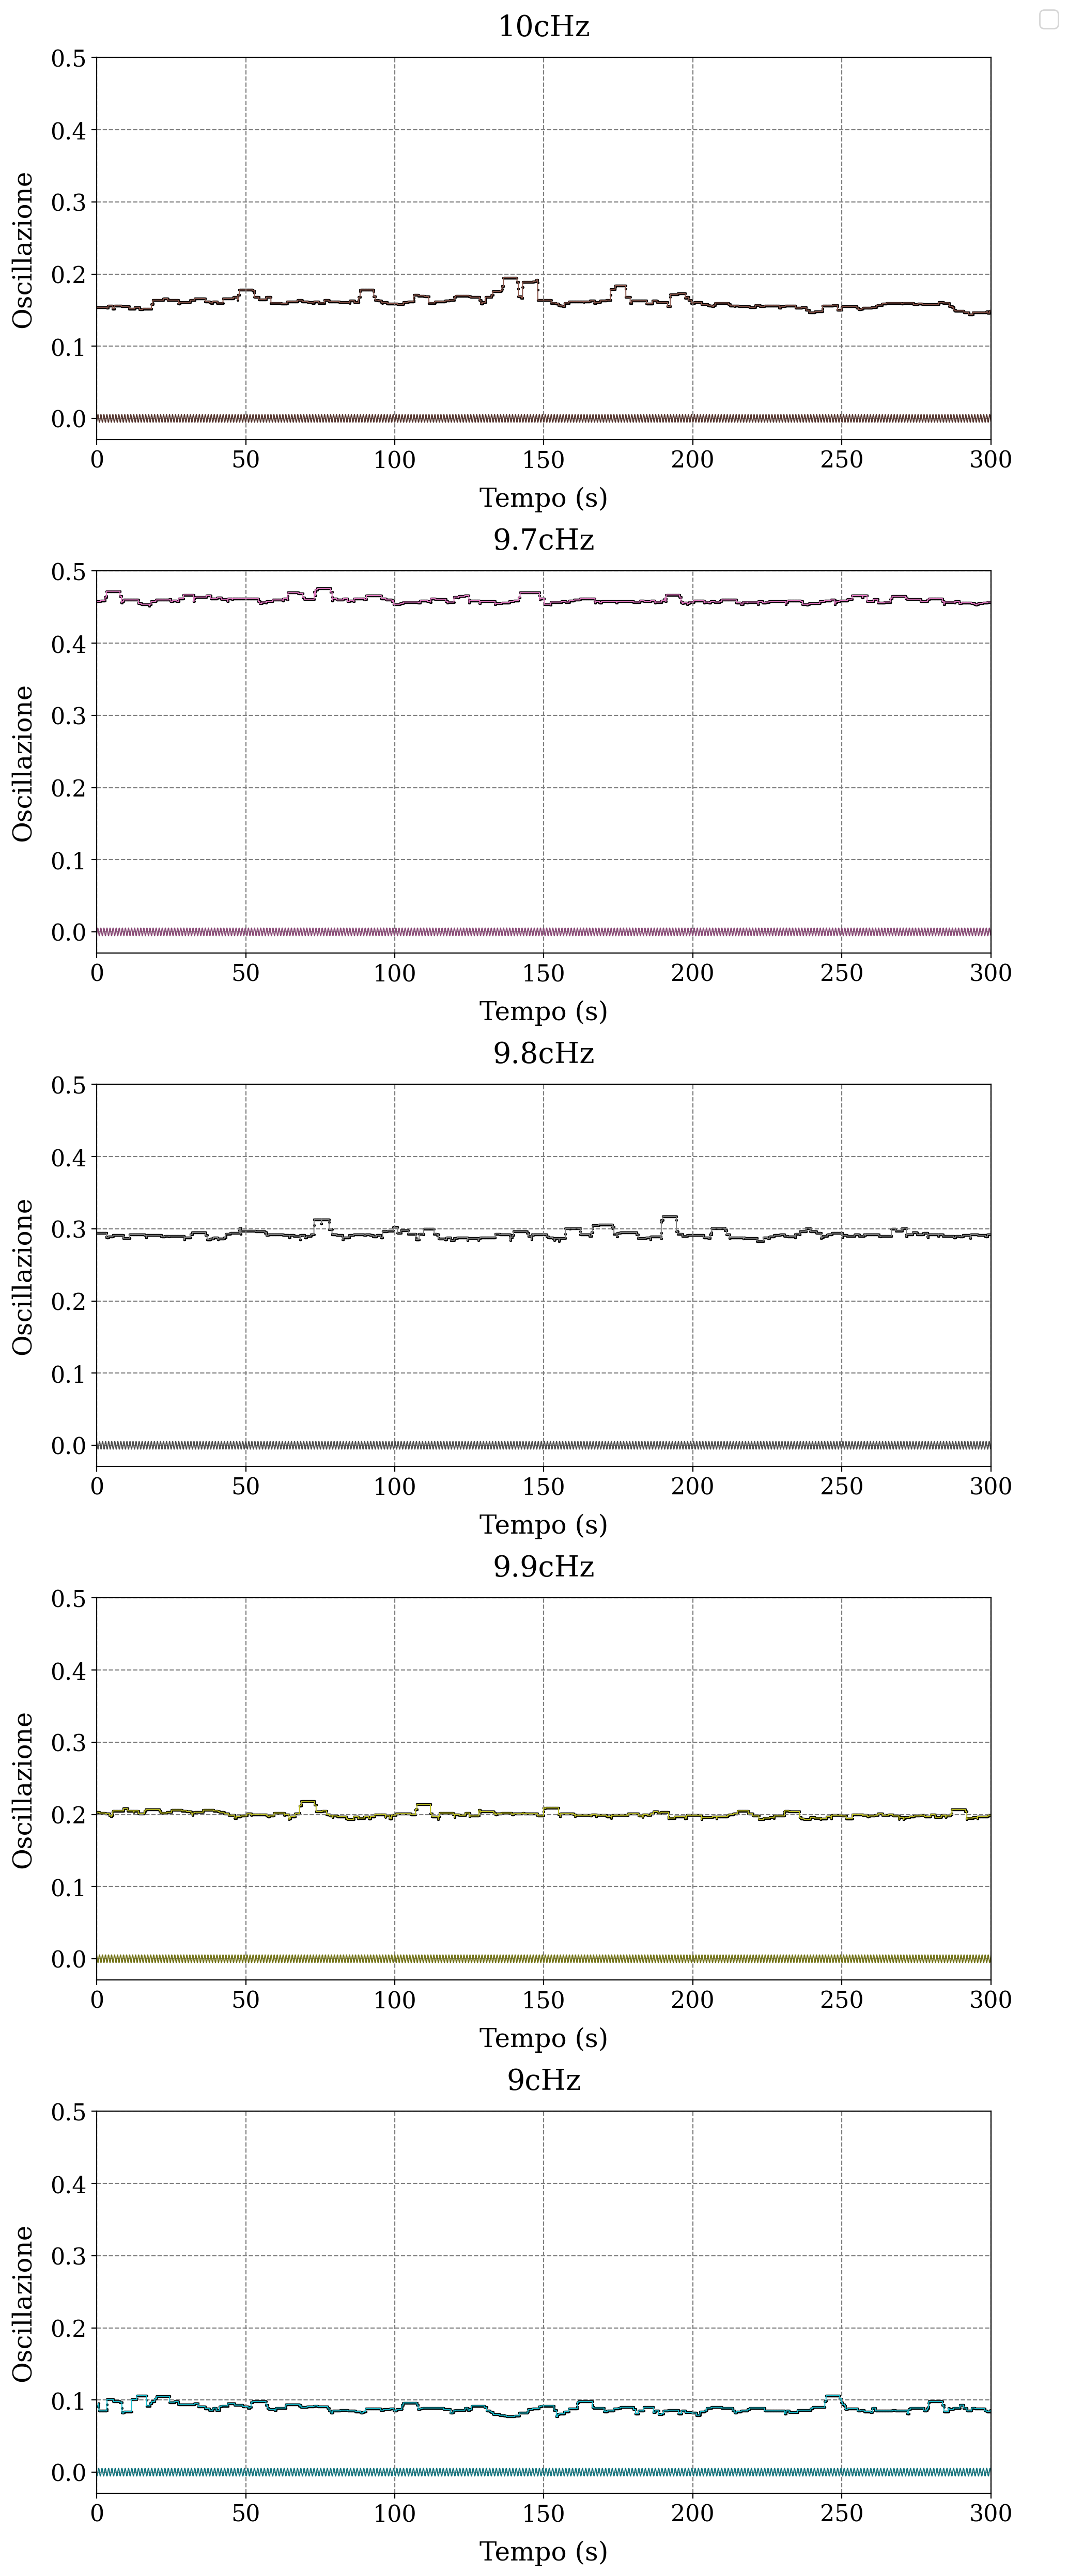

In [ ]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, input_file in enumerate(input_files):

    ax = axes[i]

    titolo = nome(input_file)
    colore = next(color_cycle)

    x = dati[titolo]["tempo"]
    y = dati[titolo]["ampiezza"] / (2*np.pi) # ampiezza (soluzione) in rad

    y2 = dati[titolo]["forzante"] / (2*np.pi) / 1000 # ampiezza forzante in rad

    ax.plot(x, y, color=colore, linewidth=0.7)
    ax.scatter(x, y, color="black", s=0.7)

    ax.plot(x, y2, color=gf.darken(colore), linewidth=0.7)
    #ax.scatter(x, y2, color="black", s=0.7)

    gf.parametri_grafico(ax, titolo, "Tempo (s)", "Oscillazione")
    ax.set_xlim(0,300)
gf.salva_grafico(fig, "./Images/Confronto.pdf")

## 2.2 Calcolo Ampiezze Medie

Raggio dell'intorno rispetto al quale i valori salvati sono i massimi. Di tali valori verrà poi calcolata la media, considerata come ampiezza media.

In [61]:
raggio = 40
grafico_controllo = False

In [62]:
ampiezze = {}

if grafico_controllo: fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, serie in enumerate(dati):
    valori = dati[serie]["pendolo"]
    tempi = dati[serie]["tempo"]
    massimi, massimi_t = [], []

    for j, val in enumerate(valori):
        if tempi[j] > 300:
            break
        if j < raggio or j > len(valori) - raggio - 1:
            continue
        if all(val > valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            massimi.append(abs(val))
            massimi_t.append(tempi[j])

    ampiezze[serie] = np.mean(massimi)

    print(f"Serie {serie}: {len(massimi)} massimi \n Media: {np.mean(massimi):.3f} \n Deviazione standard: {np.std(massimi):.3f} \n")
    
    if grafico_controllo:
        ax = axes[i]
        colore = next(color_cycle_fisso)
        ax.scatter(massimi_t, massimi, color=colore)
        gf.parametri_grafico(ax, f"Massimi {serie}", "Tempo (s)", "Ampiezza")
if grafico_controllo: gf.salva_grafico(fig, f"./Images/Massimi_{serie}.pdf")

Serie 10cHz: 249 massimi 
 Media: 0.063 
 Deviazione standard: 0.005 

Serie 9.7cHz: 256 massimi 
 Media: 0.223 
 Deviazione standard: 0.003 

Serie 9.8cHz: 242 massimi 
 Media: 0.137 
 Deviazione standard: 0.004 

Serie 9.9cHz: 240 massimi 
 Media: 0.087 
 Deviazione standard: 0.004 

Serie 9cHz: 208 massimi 
 Media: 0.031 
 Deviazione standard: 0.005 



In [55]:
gf.display_dizionario(ampiezze)

10cHz,0.06327309236947791
9.7cHz,0.22326562500000002
9.8cHz,0.13725619834710748
9.9cHz,0.08747499999999998
9cHz,0.03053846153846155


## 2.3 Fit Lorentziano

# Test

In [78]:
for i, serie in enumerate(dati):
    serie = dati[serie]

    tempi = serie['tempo']
    target = 300
    n = np.abs(np.array(tempi) - target).argmin()

    print(f"--- Serie {i+1} ---")
    print(f"Forzante: media = {np.mean(serie['forzante'][:n]):.3f}, deviazione = {np.std(serie['forzante'][:n], ddof=1):.3f}")
    print(f"Pendolo:  media = {np.mean(serie['pendolo'][:n]):.3f},  deviazione = {np.std(serie['pendolo'][:n], ddof=1):.3f}")
    print(f"Ampiezza: media = {np.mean(serie['ampiezza'][:n]):.3f}, deviazione = {np.std(serie['ampiezza'][:n], ddof=1):.3f}")
    print(f"Fase:     media = {np.mean(serie['fase'][:n]):.3f},     deviazione = {np.std(serie['fase'][:n], ddof=1):.3f}\n")

--- Serie 1 ---
Forzante: media = 0.158, deviazione = 23.771
Pendolo:  media = -0.013,  deviazione = 0.052
Ampiezza: media = 0.162, deviazione = 0.009
Fase:     media = 15.009,     deviazione = 1.253

--- Serie 2 ---
Forzante: media = 0.162, deviazione = 23.775
Pendolo:  media = -0.004,  deviazione = 0.159
Ampiezza: media = 0.460, deviazione = 0.004
Fase:     media = 44.750,     deviazione = 0.640

--- Serie 3 ---
Forzante: media = 0.133, deviazione = 23.776
Pendolo:  media = -0.006,  deviazione = 0.099
Ampiezza: media = 0.293, deviazione = 0.006
Fase:     media = 27.823,     deviazione = 0.483

--- Serie 4 ---
Forzante: media = 0.123, deviazione = 23.769
Pendolo:  media = -0.009,  deviazione = 0.067
Ampiezza: media = 0.201, deviazione = 0.004
Fase:     media = 19.695,     deviazione = 0.491

--- Serie 5 ---
Forzante: media = 0.149, deviazione = 23.809
Pendolo:  media = -0.009,  deviazione = 0.024
Ampiezza: media = 0.089, deviazione = 0.006
Fase:     media = 40.059,     deviazione = 17